# Изучение рынка заведений общественного питания Москвы

- Автор: Земцова Ксения
- Дата: 17.02.2026

### Цели и задачи проекта

<font color='#777778'> Цель: Провести исследовательский анализ данных рынка заведений общественного питания Москвы.
    
Задачи:
1. Загрузить данные и познакомиться с их содержимым.
2. Провести предобработку данных.
3. Провести исследовательский анализ данных:
    - изучить данные более детально;
    - изучить категории заведений;
    - распределение заведений по административным районам Москвы;
    - соотношение сетевых и несетевых заведений;
    - количество посадочных мест в заведениях;
    - рейтинг заведений;
    - взаимосвязь рейтинга заведений и других показателей;
    - топ-15 популярных сетей в Москве;
    - средний чек.
4. Сформулировать выводы по проведённому анализу.</font>

### Описание данных

<font color='#777778'>Для анализа поступили данные о заведениях общественного питания Москвы на основе информации сервисов Яндекс Карты и Яндекс Бизнес за лето 2022 года. Данные состоят из двух датасетов:

- `rest_info.csv` — информация о заведениях общественного питания;
- `rest_price.csv` — информация о среднем чеке в заведениях общественного питания.
    
#### Описание датасета `rest_info`

- `name` — название заведения;
- `address` — адрес заведения;
- `district` — административный район, в котором находится заведени;
- `category` — категория заведени;
- `hours` — информация о днях и часах работы;
- `rating` — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);
- `chain` — является ли заведение сетевым (для маленьких сетей могут встречаться ошибки);
- `seats` — количество посадочных мест.

#### Описание датасета `rest_price`

- `price` — категория цен в заведении;
- `avg_bill` — хранит среднюю стоимость заказа в виде диапазона;
- `middle_avg_bill` — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»;
- `middle_coffee_cup` — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино».
</font>

### Содержимое проекта

<font color='#777778'>
1. Загрузка данных и знакомство с ними.
2. Предобработка данных.
3. Исследовательский анализ данных.
4. Итоговые выводы.
</font>

---

## Загрузка данных и знакомство с ними


Начнём с загрузки библиотек и датасетов `rest_info.csv` и `rest_price.csv`. Будем использовать pandas и библиотеки визуализации данных matplotlib и seaborn, а также phik для построения матрицы корреляции. Данные датасетов сохраним в двух переменных: `info_df` и `price_df`.

In [1]:
# Импортируем библиотеки
import pandas as pd

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns
!pip install phik

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Выгружаем данные в переменные info_df и price_df
info_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
price_df = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')

Познакомимся с данными и изучим общую информацию о них.

In [3]:
# Выводим первые строки датафрейма info_df на экран
info_df.head(50)

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0
5,8a343546b24e4a499ad96eb7d0797a8a,Sergio Pizza,пиццерия,"Москва, Ижорская улица, вл8Б",Северный административный округ,"ежедневно, 10:00–23:00",4.6,0,NaN
6,96ebceb1a09e4e3191133b9fe0379a64,Огни города,"бар,паб","Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,пн 15:00–04:00; вт-вс 15:00–05:00,4.4,0,45.0
7,0243288b78024af090b8e947842c969c,Mr. Уголёк,быстрое питание,"Москва, Клязьминская улица, 9, стр. 3",Северный административный округ,"пн-чт 10:00–22:00; пт,сб 10:00–23:00; вс 10:00...",4.7,0,45.0
8,36aeb0ffa69c48fdb0021549520deb10,Donna Maria,ресторан,"Москва, Дмитровское шоссе, 107, корп. 4",Северный административный округ,"ежедневно, 10:00–22:00",4.8,0,79.0
9,487167877eb04288bc90d4fa80646fc2,Готика,кафе,"Москва, Ангарская улица, 39",Северный административный округ,"ежедневно, 12:00–00:00",4.3,0,65.0


In [4]:
# Выводим информацию о датафрейме info_df
info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [5]:
# Выводим первые строки датафрейма price_df на экран
price_df.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [6]:
# Выводим информацию о датафрейме price_df
price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделаем промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметим другие особенности данных, которые обнаружены на этой стадии и на которые стоит обратить внимание при предобработке.

Датасет `rest_info.csv` содержит 9 столбцов и 8406 строк, в которых представлена информация о заведениях общественного питания Москвы.

После первичного анализа данных можно сделать следующие выводы:

- Столбцы `rating`, `chain`, `seats` содержат числовые значения и хранятся в типах данных int64 или float64, размерность данных можно оптимизировать. Также можно изменить тип данных столбца `seats` можно поменять на int, так как количество посадочных мест представлено целым числом. 
- Остальные столбцы содержат текст и представлены типом object. 
- Пропуски содержатся только в столбцах `hours`, `seats`. Однако следует проверить и другие столбцы: в них могут встречаться значения-индикаторы, которые будут говорить об отсутствии данных.

Судя по первому знакомству с данными, значения в столбцах соответствуют своему описанию.
Теперь познакомимся с данными датасета `rest_price.csv`.

Датасет `rest_price.csv` содержит 5 столбцов и 4058 строк, в которых представлена информация о ценах в заведениях общественного питания Москвы. По аналогии с предыдущим датасетом можно отметить, что:

- Типы данных соответствуют содержимому. Тип данных для столбцов `middle_avg_bill` и `middle_coffee_cup` можно оптимизировать с понижением размерности. Маловероятно, что онb хранzт сильно завышенные значения.
- Пропусков есть, но по логике хранения данных они допустимы, так как не для всех заведений приведена информациях о ценах и среднем чеке.
- Значения в столбцах соответствуют описанию.

Первичное знакомство показывает, что данные хорошего качества — они соответствуют описанию и выглядят корректными. Настало время следующего этапа — предобработки данных.

### Подготовка единого датафрейма

Объединим данные двух датасетов в один, с которым продолжим работу.

Задача проекта предполагает комплексный анализ заведений общественного питания Москвы. Поэтому можно соединить данные о заведениях из таблицы `info_df`, с данными о ценах из таблицы `price_df`.

Каждая строка в этих датафреймах — это информация о заведении, поэтому такие данные удобно соединить в один датафрейм, который можно использовать для поиска закономерностей в данных. Соединять данные будем по идентификатору заведения. При соединении оставим только полные данные — это значит, что значение `id` заведения должно быть в двух датафреймах.

Соединим данные, используя значение параметра `how` `'left'`. Это позволит оставить больше информации о заведениях, даже если для них не будет данных о ценах.

In [7]:
# Соединяем данные в единый датафрейм df
df = info_df.merge(price_df, on='id', how='left')

In [8]:
# Выводим информацию о датафрейме
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 919.4+ KB


## Предобработка данных

Подготовим данные к исследовательскому анализ. Изучим корректность типов данных и при необходимости проведем их преобразование.

Для оптимизации типа данных будем использовать метод `pd.to_numeric` с аргументом `downcast='integer'`.

In [9]:
# Оптимизируем целочисленный тип данных в датафрейме df
df['chain'] = pd.to_numeric(df['chain'], downcast='integer')

# Оптимизируем тип чисел с плавающей точкой данных в датафрейме clients_df
for column in ['seats','rating','middle_avg_bill', 'middle_coffee_cup']:
    df[column] = pd.to_numeric(df[column], downcast='float')

In [10]:
# Проверим типы данных в датафрейме df с помощью атрибута dtypes
df.dtypes

id                    object
name                  object
category              object
address               object
district              object
hours                 object
rating               float32
chain                   int8
seats                float32
price                 object
avg_bill              object
middle_avg_bill      float32
middle_coffee_cup    float32
dtype: object

Изучим пропущенные значения в данных: посчитаем их количество в каждом столбце датафрейме, изучим данные с пропущенными значениями и предположим гипотезы их появления. Проведем обработку пропущенных значений.

При первичном анализе мы обнаружили пропуски в столбце `hours`, `seats`, `avg_bill`, `middle_avg_bill`,  `middle_coffee_cup` датафрейма `df`. Узнаем абсолютное и относительное количество пропусков.

In [11]:
# Применяем метод isna() к датафрейму df
df.isna().sum()

id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

In [12]:
# Подсчитываем долю строк с пропусками
df.isna().sum() / df.shape[0]

id                   0.000000
name                 0.000000
category             0.000000
address              0.000000
district             0.000000
hours                0.063764
rating               0.000000
chain                0.000000
seats                0.429574
price                0.605639
avg_bill             0.546039
middle_avg_bill      0.625387
middle_coffee_cup    0.936355
dtype: float64

В датафрейме `df` обнаружены пропуски:
- 8 пропусков в столбце `hours`  — это 6% данных. Количество пропусков больше 5%, поэтому не можем удалить их.
- 1539 пропусков в столбце `seats` — это 43% данных. Количество пропусков достаточно большое, но цель исследования — проанализировать данные в их исходном виде, поэтому не заполняем пропуски и оставляем их.
- 743 пропусков в столбцев `price` — это 61% данных. Аналогично с прошлым столбцом.
- 242 пропуска в столбце `avg_bill` — 55% данных. Столбец заполнен текстом, поэтому нет смысла его трогать.
- 909 пропусков в столбце `middle_avg_bill` — 63%. Пропуски связаны с тем, что `avg_bill` не начинает на "Средний счёт" или заполнено поле `middle_coffee_cup`, так как была приведена цена кофе. Не трогаем, пропуски допустимы.
- 3523 пропусков в столбце `middle_coffee_cup` — 94%, обрабатываем аналогично с прошлым столбцом.


Проверим данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуем данные в текстовых столбцах, например с названием заведения.

In [13]:
# Удаляем явные дубликаты по id, оставляя первое вхождение
# Запоминаем исходный размер
initial_count = len(df)

# Удаляем дубликаты
df = df.drop_duplicates(subset=['id'], keep='first')

# Вычисляем количество удаленных дубликатов
removed_count = initial_count - len(df)
print(f"Удалено дубликатов: {removed_count}")

Удалено дубликатов: 0


In [14]:
# Нормализуем название и адрес (удаляем пробелы, приводим к нижнему регистру)
df['name'] = df['name'].str.lower().str.strip()
df['address'] = df['address'].str.lower().str.strip()

In [15]:
# Проверка дубликатов по комбинации название + адрес
duplicates_name_address = df[df.duplicated(['name', 'address'], keep=False)]
print(f"Всего строк с дубликатами по названию и адресу: {len(duplicates_name_address)}")

Всего строк с дубликатами по названию и адресу: 8


Для дальнейшей работы создадим столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [16]:
# Выедем все уникальные значения столбца hours, чтобы понять форматы записи
df['hours'].unique()

array(['ежедневно, 10:00–22:00',
       'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00',
       'ежедневно, 09:00–22:00', ...,
       'пн-пт 08:30–21:30; сб,вс 09:00–21:30',
       'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00',
       'пн-сб 10:30–21:30'], dtype=object)

In [17]:
# Функция для определения круглосуточного режима
def check_24_7(hours_str):
    if pd.isna(hours_str):
        return False
    
    hours_str = str(hours_str).lower()
    
    # Одно ключевое слово для проверки
    keyword = 'ежедневно, круглосуточно'
    
    if keyword in hours_str:
        return True
    
    return False

# Применяем функцию
df['is_24_7'] = df['hours'].apply(check_24_7)

# Проверяем результат
print("Круглосуточные заведения:")
print(df[df['is_24_7']][['name', 'hours', 'category']].head(10))

true_count = df['is_24_7'].sum()
print(f"Количество круглосуточных заведений: {true_count}")

Круглосуточные заведения:
                  name                     hours         category
10      great room bar  ежедневно, круглосуточно          бар,паб
17  чайхана беш-бармак  ежедневно, круглосуточно         ресторан
19             пекарня  ежедневно, круглосуточно         булочная
24          drive café  ежедневно, круглосуточно             кафе
49             2u-ту-ю  ежедневно, круглосуточно         пиццерия
50              шаурма  ежедневно, круглосуточно  быстрое питание
54              шашлык  ежедневно, круглосуточно  быстрое питание
61           кафе лоза  ежедневно, круглосуточно         ресторан
70           гуава бар  ежедневно, круглосуточно          бар,паб
84    meat doner kebab  ежедневно, круглосуточно         булочная
Количество круглосуточных заведений: 730


---

### Промежуточный вывод

После предобработки данных напишим промежуточный вывод о проведённой работе. Отразим количество или долю отфильтрованных данных, вы что-то удаляли.

При первичном анализе мы обнаружили пропуски в столбце `hours`, `seats`, `avg_bill`, `middle_avg_bill`,  `middle_coffee_cup` датафрейма `df` и провели работу с ними. Пропуски не были удалены, так как цель исследования — проанализировать исходные данные без внесения изменений.

При работе с дубликатами нормализовали значения в стобцах `name` и `address`. Явных дубликатов не обнаружилось. Проверили неявные дубликаты по совпадению адреса и названия заведения — их также нет.

Создали столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7.

## Исследовательский анализ данных
Проведем исследовательский анализ исходных данных.

При исследовании данных используем визуализации. Проверим, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуем количество объектов общественного питания по каждой категории. Результат сопроводим подходящей визуализацией.

In [18]:
# Проверяем распределение данных по значениям столбца category
print('Распределение количества заведений по категориям:')
df['category'].value_counts()

Распределение количества заведений по категориям:


кафе               2378
ресторан           2043
кофейня            1413
бар,паб             765
пиццерия            633
быстрое питание     603
столовая            315
булочная            256
Name: category, dtype: int64

Категории заведений распределены неравномерно между количеством заведений. Самые популярные категории: кафе, ресторан и кофейня.

Для визуального анализа такого распределения можно использовать столбчатые диаграммы. Визуализируем распределение в столбце `category`:

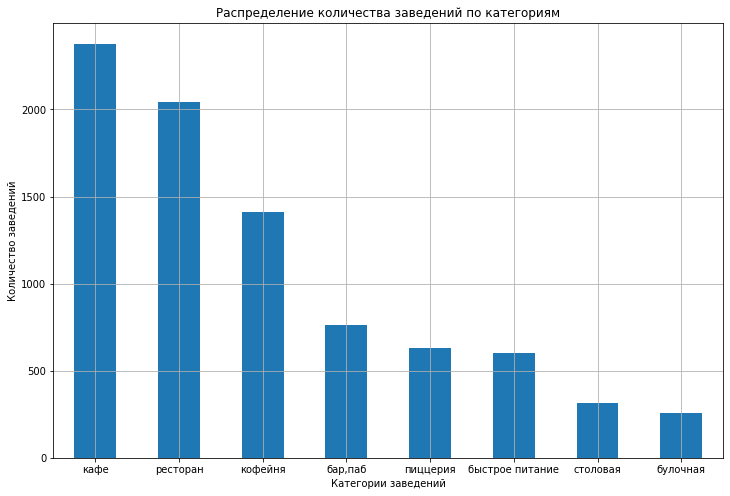

In [19]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(12, 8))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['category'].value_counts().plot(
               kind='bar', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение количества заведений по категориям'
)

# Настраиваем оформление графика
plt.xlabel('Категории заведений')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуем распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводим подходящими визуализациями.

In [20]:
# Проверяем распределение данных по значениям столбца district
print('Распределение количества заведений по административным районам Москвы:')
df['district'].value_counts()

Распределение количества заведений по административным районам Москвы:


Центральный административный округ         2242
Северный административный округ             900
Южный административный округ                892
Северо-Восточный административный округ     891
Западный административный округ             851
Восточный административный округ            798
Юго-Восточный административный округ        714
Юго-Западный административный округ         709
Северо-Западный административный округ      409
Name: district, dtype: int64

Заведения распределены неравномерно между административными районами Москвы. Самые популярные районы Москвы: Центральный административный округ, Северный административный округ.

Для визуального анализа такого распределения можно использовать столбчатые диаграммы. Визуализируем распределение в столбце `district`:

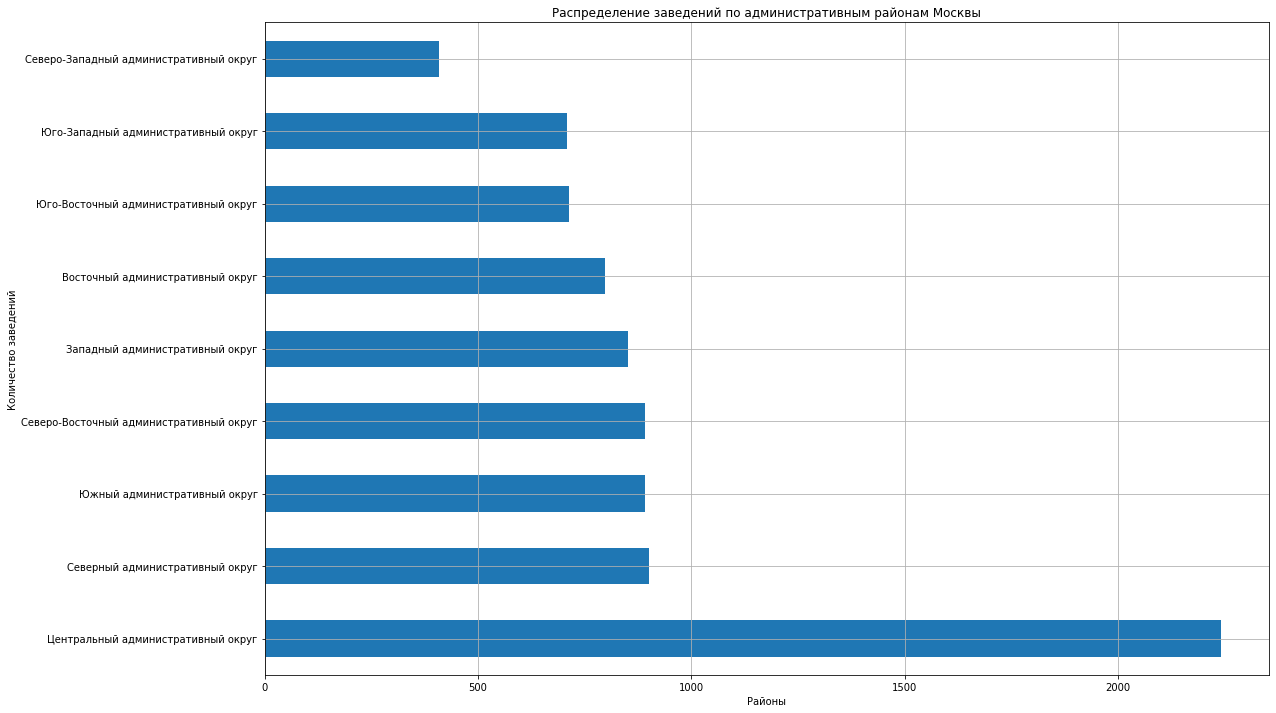

In [21]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(18, 12))

# Строим столбчатую диаграмму с помощью pandas через plot(kind='bar')
df['district'].value_counts().plot(
               kind='barh', # Тип графика - столбчатая диаграмма
               rot=0, # Градус вращения подписи по оси Х
               legend=False, # Выключаем легенду
               title=f'Распределение заведений по административным районам Москвы'
)

# Настраиваем оформление графика
plt.xlabel('Районы')
plt.ylabel('Количество заведений')
# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

В Центральном административном округе (ЦАО) сконцентрировано больше всего заведений общественного питания — 2242. Изучим подррбнее, какие категории заведений есть в ЦАО:

In [22]:
# Найдем распределение заведений в ЦАО
grouped = df[df['district'] == 'Центральный административный округ']['category'].value_counts()

print("Распределение категорий заведений в ЦАО:")
print(grouped)

Распределение категорий заведений в ЦАО:
ресторан           670
кафе               464
кофейня            428
бар,паб            364
пиццерия           113
быстрое питание     87
столовая            66
булочная            50
Name: category, dtype: int64


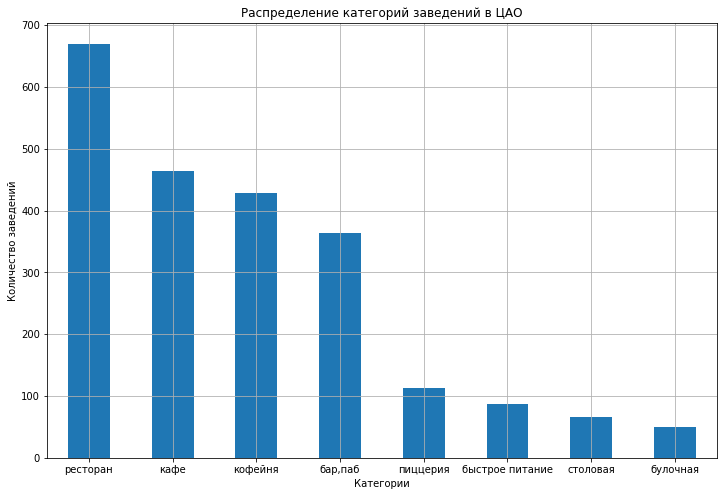

In [23]:
# Построим график столбчатой диаграммы

grouped = df[df['district'] == 'Центральный административный округ']['category'].value_counts()

grouped.plot(kind='bar',
             title='Распределение категорий заведений в ЦАО',
             legend=False,
             ylabel='Количество заведений',
             xlabel='Категории',
             rot=0,
             figsize=(12, 8))
plt.grid()

# Выводим график
plt.show()

В ЦАО преобладают следующие категории заведений:
- рестораны — 670
- бар, паб — 464
- кофейни — 428.

---

### Задача 3

Изучим соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми?

In [24]:
# Cоотношение сетевых и несетевых заведений в целом
part_chain=round(df['chain'].sum()/len(df) * 100, 2)
print(f"Количество сетевых заведений: {df['chain'].sum()}")
print(f"Количество несетевых заведений: {len(df)-df['chain'].sum()}")
print(f"Процент сетевых заведений от общего числа: {part_chain}")
print(f"Процент несетевых заведений от общего числа: {100-part_chain}")

Количество сетевых заведений: 3205
Количество несетевых заведений: 5201
Процент сетевых заведений от общего числа: 38.13
Процент несетевых заведений от общего числа: 61.87


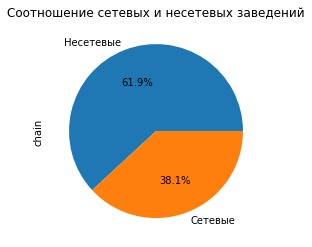

In [25]:
# Создадим визуализацию соотношения сетевых и несетевых заведений
df['chain'].value_counts().rename(index={0:'Несетевые', 1:'Сетевые'}).plot(kind='pie', autopct='%1.1f%%', title='Соотношение сетевых и несетевых заведений')
plt.show()

In [26]:
# Cоотношение сетевых и несетевых заведений в разрезе категорий
grouped = df.groupby('category')['chain'].value_counts().unstack(fill_value=0)
grouped.columns = ['Несетевые', 'Сетевые']

# Добавляем колонку с общим количеством
grouped['Всего'] = grouped['Несетевые'] + grouped['Сетевые']

grouped['% несетевых'] = round(grouped['Несетевые']/grouped['Всего']*100, 2)
grouped['% сетевых'] = 100-grouped['% несетевых']

# Сортируем по общему количеству
grouped = grouped.sort_values('Всего', ascending=False)

print("Соотношение сетевых и несетевых заведений по категориям:")
print(grouped)

Соотношение сетевых и несетевых заведений по категориям:
                 Несетевые  Сетевые  Всего  % несетевых  % сетевых
category                                                          
кафе                  1599      779   2378        67.24      32.76
ресторан              1313      730   2043        64.27      35.73
кофейня                693      720   1413        49.04      50.96
бар,паб                596      169    765        77.91      22.09
пиццерия               303      330    633        47.87      52.13
быстрое питание        371      232    603        61.53      38.47
столовая               227       88    315        72.06      27.94
булочная                99      157    256        38.67      61.33


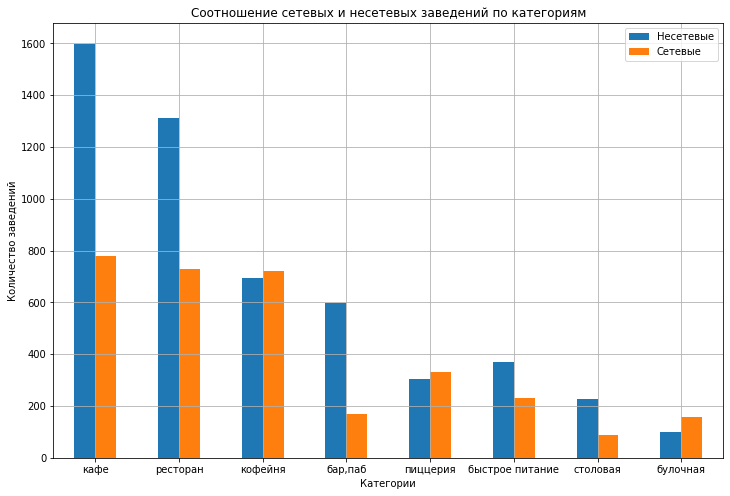

In [27]:
# Построим график столбчатой диаграммы

grouped[['Несетевые', 'Сетевые']].plot(kind='bar',
             title='Соотношение сетевых и несетевых заведений по категориям',
             legend=True,
             ylabel='Количество заведений',
             xlabel='Категории',
             rot=0,
             figsize=(12, 8))
plt.grid()

# Выводим график
plt.show()

В целом несетевых заведений больше, они составляют 61% от общего числа. 

Изучим распределение сетевых и несетевых заведений по катерориям заведений.

Топ-3 популярных категории для сетевых заведений и несетевых заведений выглядит одинаково:
1. кафе
2. ресторан
3. кофейня

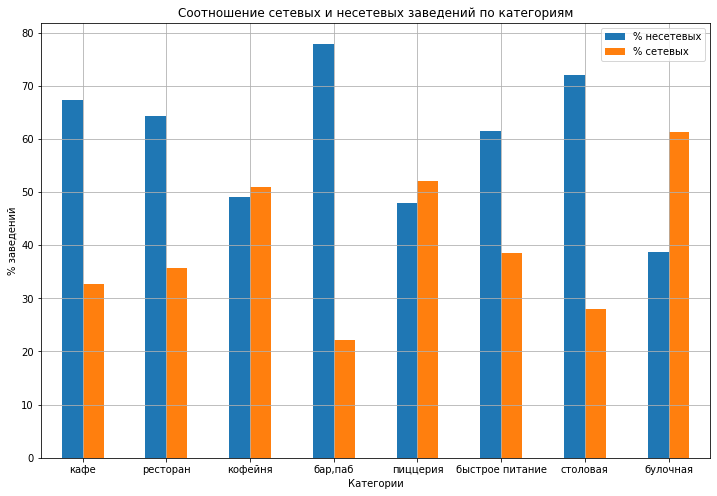

In [28]:
# Построим график столбчатой диаграммы

grouped[['% несетевых', '% сетевых']].plot(kind='bar',
             title='Соотношение сетевых и несетевых заведений по категориям',
             legend=True,
             ylabel='% заведений',
             xlabel='Категории',
             rot=0,
             figsize=(12, 8))
plt.grid()

# Выводим график
plt.show()

Рассмотрим соотношение сетевых и несетевых заведений внутри каждой категории заведений.

В категориях больше всего несетевых заведений:
1. бар, паб — 78%
2. столовая — 72%
3. кафе — 67%

В категориях больше всего сетевых заведений:
1. булочная — 61%
2. пиццерия — 52%
3. кофейня — 51%

---

### Задача 4

Исследуем количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведем для каждой категории заведений наиболее типичное для него количество посадочных мест.


In [29]:
# Изучаем статистические показатели столбца seats
print('Статистические показатели столбца seats:')
df['seats'].describe()

Статистические показатели столбца seats:


count    4795.000000
mean      108.421692
std       122.833397
min         0.000000
25%        40.000000
50%        75.000000
75%       140.000000
max      1288.000000
Name: seats, dtype: float64

Значение стандартного отклонения высокое — 122, и при среднем 108 это указывает, что данные могут иметь широкий разброс. Разница между минимальным и максимальным значениями это подтверждает.

Дополнительно проверим это. Выведем 99 процентиль и построим гистограмму распределения значений и диаграмму размаха для столбца с балансом.

In [30]:
# Выводим 99 процентиль
df['seats'].quantile(0.99)

625.0

Максимальное значение сильно превышает значение 99 процентиля, это говорит о возможной аномалии.

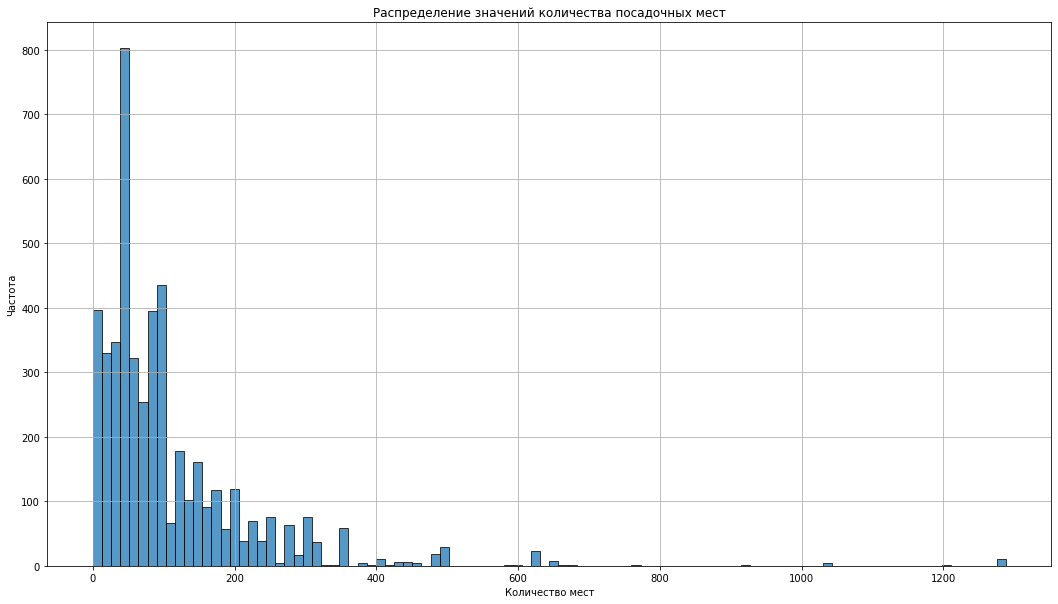

In [31]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(18, 10))


df['seats'].plot(
                kind='hist', 
                bins=100, 
                alpha=0.75,
                edgecolor='black',
                rot=0, 
)


plt.title('Распределение значений количества посадочных мест')
plt.xlabel('Количество мест')
plt.ylabel('Частота')

plt.grid()

plt.show()

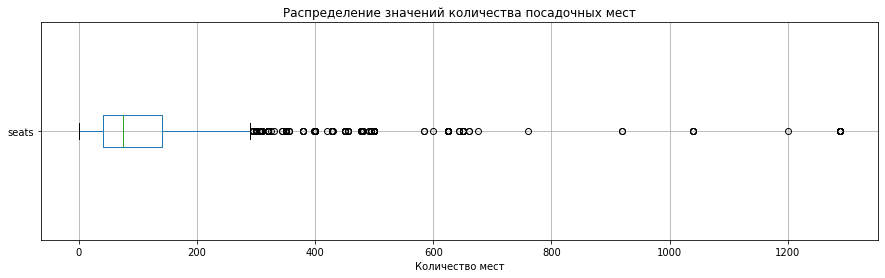

In [32]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 4))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='seats', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение значений количества посадочных мест')
plt.xlabel('Количество мест')

# Выводим график
plt.show()

Видим, что в распределении значений есть много выбросов. Изучим их детальнее, выбросами будем считать все, что больше 99 процентиля или 480 мест.

In [33]:
# Сортируем по количеству мест (от большего к меньшему)
outliers = df[df['seats'] > 480].sort_values('seats', ascending=False)
print(f"Найдено строк: {len(outliers)}")
print(outliers[['name', 'category', 'seats']])

Найдено строк: 87
                    name  category   seats
6684     пивной ресторан   бар,паб  1288.0
6808        яндекс лавка  ресторан  1288.0
6807  loft-cafe академия      кафе  1288.0
6771               точка      кафе  1288.0
6690      японская кухня  ресторан  1288.0
...                  ...       ...     ...
6683            био кафе  ресторан   495.0
6031          живое кафе   кофейня   491.0
5934               prime  ресторан   491.0
2294              bakery      кафе   481.0
2460                 495  ресторан   481.0

[87 rows x 3 columns]


In [34]:
# Посмотрим на выбросы детальнее
outliers = df[df['seats'] > 480].sort_values('seats', ascending=False)

print("АНАЛИЗ ВЫБРОСОВ\n")
print(f"Всего выбросов: {len(outliers)}")
print(f"Доля от общего числа: {len(outliers)/len(df)*100:.2f}%")

print("\nРаспределение по категориям:")
print(outliers['category'].value_counts())

print("\nРаспределение по районам:")
print(outliers['district'].value_counts())

print("\nСетевые заведения среди выбросов:")
print(f"Сетевых: {outliers['chain'].sum()}")
print(f"Несетевых: {len(outliers) - outliers['chain'].sum()}")

АНАЛИЗ ВЫБРОСОВ

Всего выбросов: 87
Доля от общего числа: 1.03%

Распределение по категориям:
ресторан           28
кафе               24
кофейня            16
бар,паб            10
пиццерия            4
столовая            2
быстрое питание     2
булочная            1
Name: category, dtype: int64

Распределение по районам:
Западный административный округ            26
Северный административный округ            23
Центральный административный округ         19
Восточный административный округ            9
Юго-Западный административный округ         5
Северо-Восточный административный округ     3
Юго-Восточный административный округ        1
Южный административный округ                1
Name: district, dtype: int64

Сетевые заведения среди выбросов:
Сетевых: 38
Несетевых: 49


Выбросы составляют менее 0.99% от всех данных и выглядят аномально, так как их показатели сильно завышены и встречаются несколько раз в некоторых выбросах. 
Аномальные показатели могут быть связаны с неправильным вводом данных из-за одинаковых повторяющихся значений.

Луше удалить выбросы — их мало и они могут искажать статистику и визуализацию.

In [35]:
# Удаляем все строки с seats > 480 (99 процентиль)
df = df[df['seats'] <= 480].copy()

In [36]:
# Найдем среднее распределение мест по категориям заведений
grouped = df.groupby('category')['seats'].mean().sort_values(ascending=False)

print("Среднее распределение мест по категориям заведений")
print(grouped)

Среднее распределение мест по категориям заведений
category
ресторан           110.045090
бар,паб            109.039299
кофейня             98.270752
быстрое питание     95.023056
столовая            89.716049
пиццерия            87.912529
кафе                86.154938
булочная            85.741493
Name: seats, dtype: float32


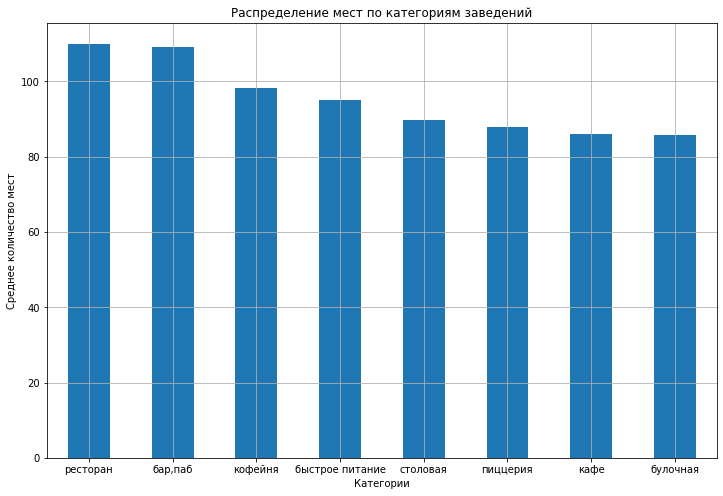

In [37]:
# Построим график столбчатой диаграммы
grouped.plot(kind='bar',
             title='Распределение мест по категориям заведений',
             legend=False,
             ylabel='Среднее количество мест',
             xlabel='Категории',
             rot=0,
             figsize=(12, 8))
plt.grid()

plt.show()

Наибольшее количество мест по среднему расчету наблюдается в следующих категориях заведений:
1. Ресторан — 110 мест
2. Бар, паб — 109 мест
3. Кофейня — 98 мест

---

### Задача 5

Исследуем рейтинг заведений. Визуализируем распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [38]:
# Изучаем статистические показатели столбца rating
df['rating'].describe()

count    4708.000000
mean        4.241271
std         0.449316
min         1.000000
25%         4.100000
50%         4.300000
75%         4.400000
max         5.000000
Name: rating, dtype: float64

In [39]:
# Изучаем средние показатели столбца rating
grouped = df.groupby('category')['rating'].agg(['mean', 'median', 'std', 'count']).round(2)
grouped = grouped.sort_values('mean', ascending=False)
print(grouped)

                 mean  median   std  count
category                                  
бар,паб          4.39     4.4  0.36    458
кофейня          4.29     4.3  0.33    735
ресторан         4.29     4.3  0.41   1242
пиццерия         4.28     4.3  0.31    423
булочная         4.26     4.3  0.42    147
столовая         4.24     4.3  0.45    162
кафе             4.15     4.3  0.54   1194
быстрое питание  4.04     4.2  0.56    347


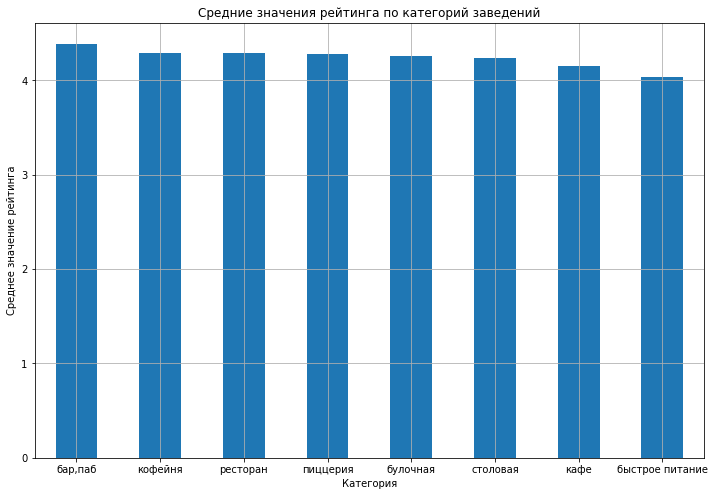

In [40]:
# Построим график столбчатой диаграммы
grouped[['mean']].plot(kind='bar',
             title='Средние значения рейтинга по категорий заведений',
             legend=False,
             ylabel='Среднее значение рейтинга',
             xlabel='Категория',
             rot=0,
             figsize=(12, 8))
plt.grid()

plt.show()

Разброс средних значений рейтинга заведений невелик и варьируется от 4,39 до 4,04.

Топ-3 категорий заведений по рейтингу:
1. Бар,паб
2. Кофейня
3. Ресторан

---

### Задача 6

Изучим, с какими данными показывают самую сильную корреляцию рейтинги заведений? Построим и визуализируем матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберем самую сильную связь и проверим её.

In [41]:
# Вычисляем корреляционную матрицу с использованием phi_k
correlation_matrix = df[['rating', 'category', 'district', 
                'chain', 'seats', 'price', 'is_24_7']].phik_matrix()

# Выводим результат
print('Корреляционная матрица с коэффициентом phi_k для переменной rating')
correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)

interval columns not set, guessing: ['rating', 'chain', 'seats']
Корреляционная матрица с коэффициентом phi_k для переменной rating


,rating
price,0.340992
category,0.204045
is_24_7,0.179179
district,0.173987
chain,0.096750
seats,0.026350


Нас интересует связь рейтинга заведения с другими данными, поэтому на экран был выведен только столбец `rating` итоговой матрицы корреляции `correlation_matrix`. Условие `correlation_matrix.loc[correlation_matrix.index != 'rating']` помогает убрать строку с индексом `'rating'`.

Самая сильная корреляционная наблюдается со столбцом `price` (0,341).

Важно помнить, что `phi_k` сообщает только о наличии связи между данными. На сам характер связи коэффициент `phi_k` не указывает, поэтому после получения коэффициента следует продолжить анализ.

Перед тем как перейти к дальнейшему анализу, визуализируем результат корреляции с помощью тепловой карты и библиотеки seaborn:

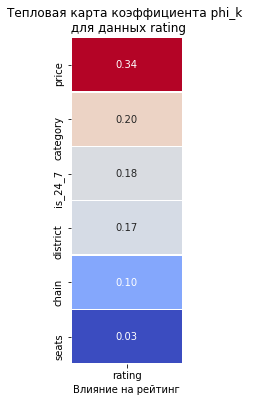

In [42]:
# Строим тепловую карту
plt.figure(figsize=(2, 6))

data_heatmap = correlation_matrix.loc[correlation_matrix.index != 'rating'][['rating']].sort_values(by='rating', ascending=False)
sns.heatmap(data_heatmap,
            annot=True, # Отображаем численные значения в ячейках карты
            fmt='.2f', # Форматируем значения корреляции: два знака после точки
            cmap='coolwarm', # Устанавливаем цветовую гамму от красного (макс. значение) к синему
            linewidths=0.5, # Форматируем линию между ячейками карты
            cbar=False # Отключаем цветовую шкалу
           )

# Добавляем заголовок и подпись по оси Х
plt.title('Тепловая карта коэффициента phi_k \n для данных rating')
plt.xlabel('Влияние на рейтинг')

# Выводим график
plt.show()

Теперь корреляция между рейтингом заведения и другими признаками наглядно отображена. Можно продолжить исследование данных.

Изучим, существует ли зависимость между рейтингом заведения и ценовой политикой. Для этого построим столбчатые диаграммы с разделением по признаку `rating` среди разных ценовых категорий:

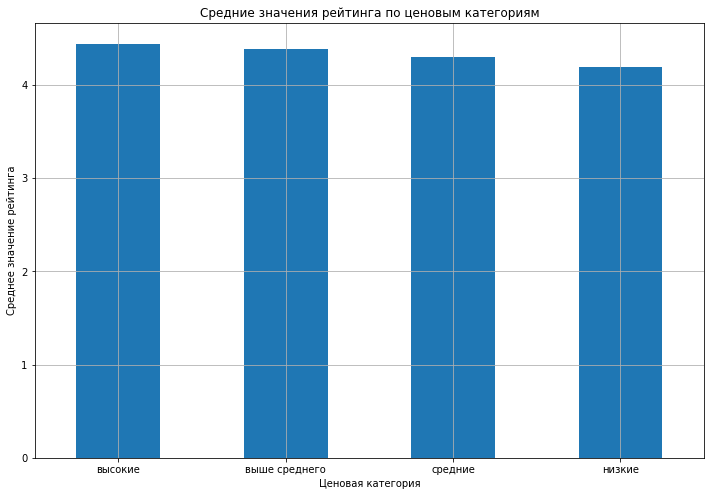

In [43]:
# Построим график столбчатой диаграммы
grouped = df.groupby('price')['rating'].mean().sort_values(ascending=False)

grouped.plot(kind='bar',
             title='Средние значения рейтинга по ценовым категориям',
             legend=False,
             ylabel='Среднее значение рейтинга',
             xlabel='Ценовая категория',
             rot=0,
             figsize=(12, 8))
plt.grid()

plt.show()

Зависимость между показателями `rating` и `price` наблюдается: чем выше ценовая категория, тем выше рейтинг заведения. Такую зависимость легко объяснить тем, что заведения с высокой ценовой категорией предлагаются более клиентоориентированное обслуживание, качественные блюда и современный дизайн.

---

### Задача 7

Сгруппируем данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитаем значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [44]:
# Выведем информацию о топ-15 популярных сетевых заведений в Москве
top_networks = df[df['chain'] == 1]['name'].value_counts().head(15)
top_networks_df = pd.DataFrame({
    'Название сети': top_networks.index,
    'Количество филиалов': top_networks.values,
    'Средний рейтинг': [df[(df['name'] == name) & (df['chain'] == 1)]['rating'].mean() for name in top_networks.index],
    'Основная категория': [df[(df['name'] == name) & (df['chain'] == 1)]['category'].mode()[0] for name in top_networks.index]
})

print("Топ-15 популярных сетевых заведений в Москве:")
print(top_networks_df.to_string(index=False))

Топ-15 популярных сетевых заведений в Москве:
                      Название сети  Количество филиалов  Средний рейтинг Основная категория
                        шоколадница                   81         4.174074            кофейня
                         додо пицца                   62         4.285483           пиццерия
                     домино'с пицца                   61         4.172132           пиццерия
                   one price coffee                   51         4.066667            кофейня
                              cofix                   36         4.116667            кофейня
                       яндекс лавка                   34         3.867647           ресторан
                         хинкальная                   32         4.262500               кафе
                              prime                   32         4.134375           ресторан
                            теремок                   27         4.099999           ресторан
кулинарная лавка братьев

Самые популярные заведеения имеют большую филиальную сеть, что напрямую влияет на их позицию. Категория популярных заведений, как правило, представлена кафе, ресторанами и кофейнями.

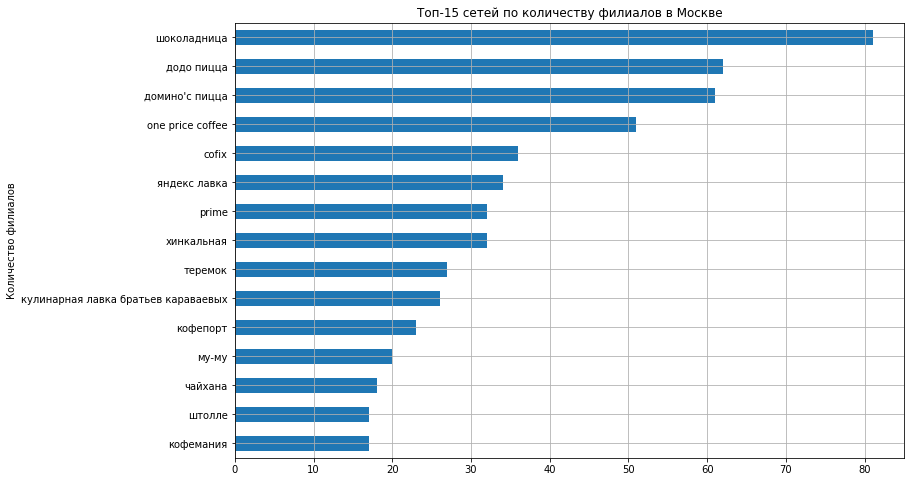

In [45]:
# Количество филиалов топ-15 сетей
top_networks_df.sort_values('Количество филиалов', ascending=True).plot(
    kind='barh',
    x='Название сети',
    y='Количество филиалов',
    title='Топ-15 сетей по количеству филиалов в Москве',
    legend=False,
    ylabel='Название сети',
    xlabel='Количество филиалов',
    rot=0,
    figsize=(12, 8)
)
plt.grid()
plt.show()

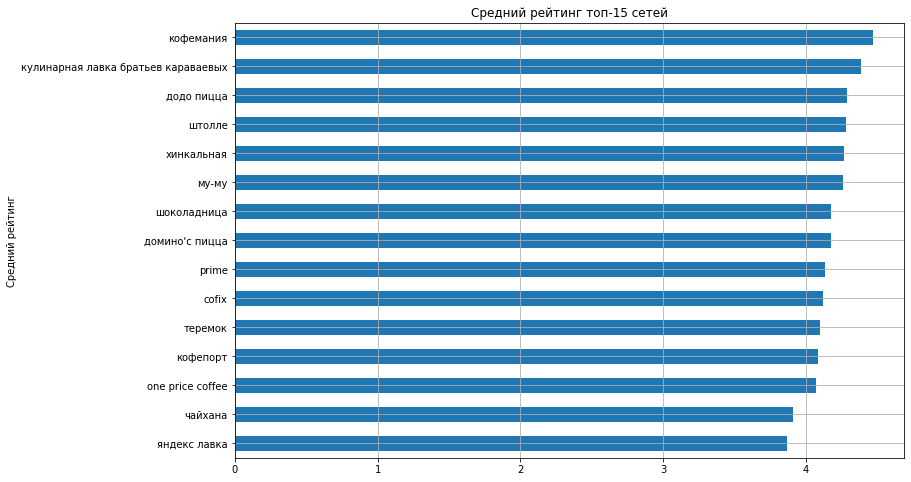

In [46]:
#Средний рейтинг топ-15 сетей
top_networks_df.sort_values('Средний рейтинг', ascending=True).plot(
    kind='barh',
    x='Название сети',
    y='Средний рейтинг',
    title='Средний рейтинг топ-15 сетей',
    legend=False,
    ylabel='Название сети',
    xlabel='Средний рейтинг',
    rot=0,
    figsize=(12, 8)
)
plt.grid()
plt.show()

Заметно, что рейтинг связан напрямую с позицией заведения по его популярности. Чем выше рейтинг заведения, тем более популярно оно.

---

### Задача 8

Изучим вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируем цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях?


In [47]:
# Изучаем статистические показатели столбца middle_avg_bill
df['middle_avg_bill'].describe()

count     1953.000000
mean       986.315430
std       1132.101807
min          0.000000
25%        387.000000
50%        750.000000
75%       1250.000000
max      35000.000000
Name: middle_avg_bill, dtype: float64

В данных заметны аномалии, так как достаточно высокое значение страндартного отклонения (1132) и большой размах между минимумом и максимумом.

Чтобы проанализировать, являются выбросы аномальными построим визуализацию и выведем значения выше 99 процентиля:

In [48]:
# Значения middle_avg_bill выше 99 процентиля
percentile_99 = df['middle_avg_bill'].quantile(0.99)
high_bill = df[df['middle_avg_bill'] > percentile_99].sort_values('middle_avg_bill', ascending=False)

print(high_bill[['name', 'category', 'middle_avg_bill']])

                          name  category  middle_avg_bill
7177                      кафе  ресторан          35000.0
730                    чойхона   бар,паб          11000.0
3882              white rabbit  ресторан           7250.0
3396                     марио  ресторан           7000.0
3487  800°с contemporary steak  ресторан           7000.0
3518                     чайка  ресторан           6500.0
3910       кантинетта антинори  ресторан           6000.0
3038                   беллини  ресторан           5250.0
4110           piazza italiana  ресторан           5000.0
3935           ресторан бабель  ресторан           5000.0
3925                   бистрот  ресторан           5000.0
317                     vоdный  ресторан           5000.0
3476                   маритим  ресторан           5000.0
5226                  кранцлер   бар,паб           4750.0
3878                   сахалин  ресторан           4500.0
1765               крабыкутабы  ресторан           4500.0
1432          

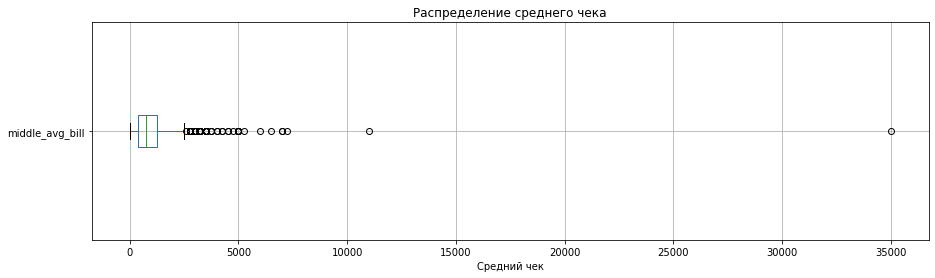

In [49]:
# Создаём контейнер графика matplotlib и задаём его размер
plt.figure(figsize=(15, 4))

# Строим диаграмму размаха значений в столбце balance
df.boxplot(column='middle_avg_bill', vert=False)

# Добавляем заголовок и метки оси
plt.title('Распределение среднего чека')
plt.xlabel('Средний чек')

# Выводим график
plt.show()

По названию и категории заведения проанализируем, является ли значения среднего чека выше 99 процентиля аномальными. 
Анамальным выглядит значение 35000, так как ресторан называется `кафе`. Удалим его.

In [50]:
# Удаляем аномальное значение
df = df[df['middle_avg_bill'] != 35000].copy()

---


Проведем анализ среднего чека в зависимости от удаленности аведений от центра Москвы:

In [51]:
# 1. Создаем группы удаленности от центра
central_districts = ['Центральный административный округ']

# Близкие к центру округа (все остальные из списка)
near_center = [
    'Северный административный округ',
    'Северо-Восточный административный округ',
    'Северо-Западный административный округ',
    'Западный административный округ',
    'Восточный административный округ',
    'Юго-Восточный административный округ',
    'Южный административный округ',
    'Юго-Западный административный округ'
]

# Добавляем колонку с группой удаленности
df['distance_group'] = 'Близко к центру'  # значение по умолчанию
df.loc[df['district'].isin(central_districts), 'distance_group'] = 'Центр'

# 2. Базовая статистика по группам
print("АНАЛИЗ ЦЕН В ЗАВИСИМОСТИ ОТ УДАЛЕННОСТИ ОТ ЦЕНТРА")

# Статистика по группам
distance_stats = df.groupby('distance_group')['middle_avg_bill'].agg(['mean', 'median', 'std', 'min', 'max', 'count']).round(2)
print("\nСтатистика по группам удаленности:")
print(distance_stats)

# 3. Сравнение Центра с остальными
center_mean = df[df['distance_group'] == 'Центр']['middle_avg_bill'].mean()
near_mean = df[df['distance_group'] == 'Близко к центру']['middle_avg_bill'].mean()

print("\nСравнение средних чеков:")
print(f"Центр: {center_mean:.2f}")
print(f"Близко к центру: {near_mean:.2f}")
print(f"Разница: {center_mean - near_mean:.2f} ({((center_mean/near_mean)-1)*100:.1f}%)")

АНАЛИЗ ЦЕН В ЗАВИСИМОСТИ ОТ УДАЛЕННОСТИ ОТ ЦЕНТРА

Статистика по группам удаленности:
                        mean  median      std   min      max  count
distance_group                                                     
Близко к центру   846.239990   600.0   704.37  30.0  11000.0   1363
Центр            1252.709961  1000.0  1010.64   0.0   7250.0    589

Сравнение средних чеков:
Центр: 1252.71
Близко к центру: 846.24
Разница: 406.46 (48.0%)


Заметно, что в центре (Центральный административный округ) средний чек в среднем больше на 48%, чем в небольшом отдаленнии от центра. Визиуализируем распределение средней стоимости чека в зависимости от удаленности от центра:

Построим два графика со средней и медианной величиной чека, распределим их по категориям заведений и в зависимости от удаленности от центра.

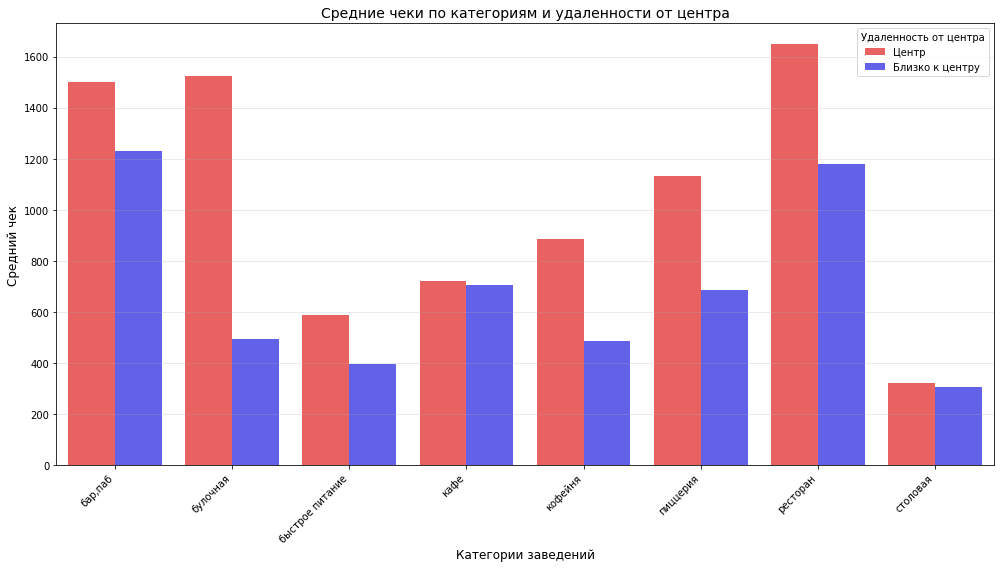

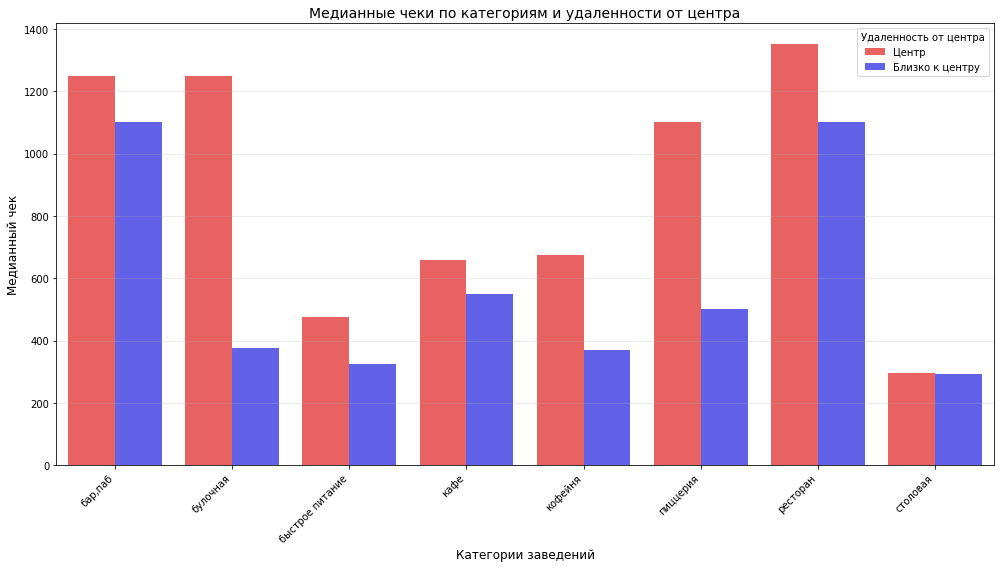

In [52]:
# Создаем две версии данных для средних и медианных значений
df_mean = df.groupby(['category', 'distance_group'])['middle_avg_bill'].mean().reset_index()
df_mean.columns = ['category', 'distance_group', 'value']

df_median = df.groupby(['category', 'distance_group'])['middle_avg_bill'].median().reset_index()
df_median.columns = ['category', 'distance_group', 'value']

# ГРАФИК 1: Средние чеки
plt.figure(figsize=(14, 8))
sns.barplot(data=df_mean, x='category', y='value', hue='distance_group', 
            hue_order=['Центр', 'Близко к центру'],
            palette=['red', 'blue'], alpha=0.7)

plt.title('Средние чеки по категориям и удаленности от центра', fontsize=14)
plt.xlabel('Категории заведений', fontsize=12)
plt.ylabel('Средний чек', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Удаленность от центра')
plt.tight_layout()
plt.show()

# ГРАФИК 2: Медианные чеки
plt.figure(figsize=(14, 8))
sns.barplot(data=df_median, x='category', y='value', hue='distance_group', 
            hue_order=['Центр', 'Близко к центру'],
            palette=['red', 'blue'], alpha=0.7)

plt.title('Медианные чеки по категориям и удаленности от центра', fontsize=14)
plt.xlabel('Категории заведений', fontsize=12)
plt.ylabel('Медианный чек', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Удаленность от центра')
plt.tight_layout()
plt.show()

Значения медианного и среднего чека пропорциональны друг другу внутри категорий и округов удаленности от центра и в числовом выражении различаются незначительно. Значения медианного чека немного меньше значений среднего.

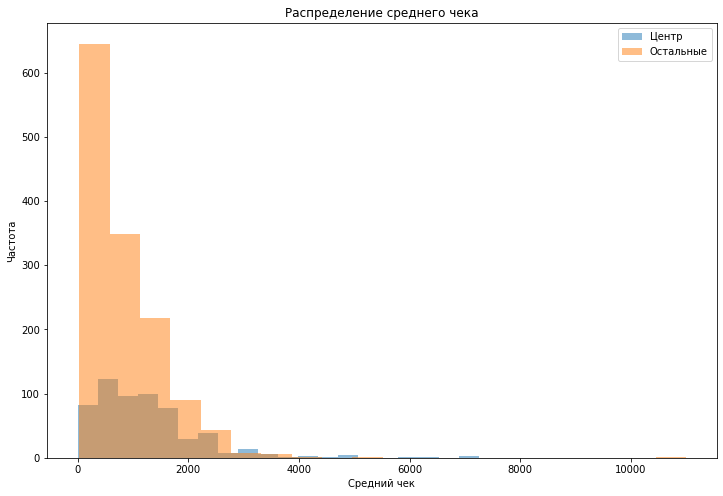

In [53]:
# Гистограммы распределения для двух групп
plt.figure(figsize=(12, 8))
df[df['distance_group'] == 'Центр']['middle_avg_bill'].hist(alpha=0.5, label='Центр', bins=20)
df[df['distance_group'] != 'Центр']['middle_avg_bill'].hist(alpha=0.5, label='Остальные', bins=20)
plt.title('Распределение среднего чека')
plt.xlabel('Средний чек')
plt.ylabel('Частота')
plt.legend()
plt.grid()
plt.show()

---

### Промежуточный вывод

Обобщим полученные результаты, выдели самые важные.

1. Категории заведений распределены неравномерно между количеством заведений. Самые популярные категории: кафе, ресторан и кофейня.

2. Заведения распределены неравномерно между административными районами Москвы. Самые популярные районы Москвы: Центральный административный округ, Северный административный округ. 
В ЦАО преобладают следующие категории заведений:
- рестораны — 670
- бар, паб — 464
- кофейни — 428.

3. В целом несетевых заведений больше, они составляют 61% от общего числа.

В категориях больше всего несетевых заведений:
- бар, паб — 78%
- столовая — 72%
- кафе — 67%

В категориях больше всего сетевых заведений:
- булочная — 61%
- пиццерия — 52%
- кофейня — 51%

4. Выбросы составляют менее 0.99% от всех данных и выглядят аномально, так как показатели сильно завышены и встречаются несколько раз в некоторых выбросах. Аномальные показатели могут быть связаны с неправильным вводом данных из-за одинаковых повторяющихся значений.

Наибольшее количество мест по среднему расчету наблюдается в следующих категориях заведений:
1. Ресторан — 110 мест.
2. Бар, паб — 109 мест.
3. Кофейня — 98 мест.


5. Разброс средних значений рейтинга заведений невелик и варьируется от 4,39 до 4,04.

Топ-3 категорий заведений по рейтингу:
1. Бар,паб
2. Кофейня
3. Ресторан


6. Самая сильная корреляционная наблюдается со столбцом price (0,341). Зависимость между показателями rating и price наблюдается: чем выше ценовая категория, тем выше рейтинг заведения. Такую зависимость легко объяснить тем, что заведения с высокой ценовой категорией предлагаются более клиентоориентированное обслуживание, качественные блюда и современный дизайн. 


7. Самые популярные заведеения имеют большую филиальную сеть, что напрямую влияет на их позицию. Категория популярных заведений, как правило, представлена кафе, ресторанами и кофейнями. Рейтинг связан напрямую с позицией заведения по его популярности. Чем выше рейтинг заведения, тем более популярно оно.


8. В данных обнаружены аномалии, так как достаточно высокое значение страндартного отклонения (1132) и большой размах между минимумом и максимумом. В центре (Центральный административный округ) средний чек в среднем больше на 48%, чем в небольшом отдаленнии от центра. Значения медианного и среднего чека пропорциональны друг другу внутри категорий и округов удаленности от центра и в числовом выражении различаются незначительно.

## Итоговый вывод и рекомендации

По результатам проведённого исследовательского анализа данных сформулируем итоговый вывод и рекомендации для заказчика по структуре:

1. Общий обзор проделанной работы.
2. Ответы на исследовательские вопросы, или главные выводы.
3. Рекомендации на основе анализа данных.

### Общий обзор

В ходе работы был проведен комплексный исследовательский анализ данных о рынке заведений общественного питания Москвы. Данные были объединены в единый датафрейм, содержащий информацию о 8406 заведениях.

На первом этапе была выполнена тщательная предобработка данных:

1. Проверена корректность типов данных и проведена их оптимизация.
2. Проанализированы и оставлены без изменений пропуски в данных, чтобы сохранить исходную картину.
3. Удалены явные дубликаты и нормализованы текстовые поля (названия и адреса) для поиска неявных дубликатов.
4. Создан новый признак is_24_7, позволяющий идентифицировать круглосуточные заведения.
5. Выявлены и удалены аномальные значения (выбросы) в показателях количества посадочных мест и среднего чека, чтобы предотвратить их искажающее влияние на результаты анализа.

### Ответы на исследовательские вопросы и главные выводы

Анализ данных позволил сформировать четкое представление о рынке общественного питания Москвы:

1. Структура рынка и география: рынок неоднороден. Лидирующие позиции по количеству заведений занимают кафе, рестораны и кофейни. Наблюдается высокая концентрация бизнеса в Центральном административном округе (ЦАО), где преобладают рестораны и бары/пабы. Это подтверждает, что центр является основной локацией для развития бизнеса в этой сфере.

2. Сетевые и несетевые форматы: большинство заведений Москвы (около 61%) являются несетевыми. Среди сетевых игроков наибольшее распространение получили кафе и рестораны. Однако, ключевой вывод здесь — размер сети не гарантирует высокого рейтинга. Это указывает на то, что лояльность клиентов и их оценки формируются под влиянием других, более важных факторов, в первую очередь — качества еды и сервиса.

3. Рейтинги и факторы влияния: разброс средних рейтингов между категориями заведений невелик (от 4,04 до 4,39), что говорит об общем высоком уровне конкуренции за качество. Наиболее высокие средние оценки у баров/пабов, пиццерий и ресторанов. Корреляционный анализ показал самую сильную связь между рейтингом и ценовой категорией (price). Заведения с более высокими ценами, как правило, имеют и более высокий рейтинг, что, вероятно, связано с более качественным сервисом, интерьером и продуктами.

4. Ценообразование и местоположение: анализ среднего чека выявил критическую зависимость цен от расположения заведения. В Центральном административном округе средний чек на 48% выше, чем в районах, прилегающих к центру. Эта разница прослеживается как в средних, так и в медианных значениях по всем категориям заведений. Это подтверждает, что близость к центру является одним из главных ценообразующих факторов.

5. Выбросы и аномалии: в ходе анализа были обнаружены и удалены аномальные значения, такие как рекордное количество посадочных мест (более 480) и нереалистично высокий средний чек (например, 35 000 рублей в заведении с названием "кафе"). Эти данные составляют менее 1% от выборки и были исключены для обеспечения чистоты анализа.

### Рекомендации на основе анализа данных

На основе полученных выводов можно дать следующие рекомендации потенциальным инвесторам и действующим игрокам рынка:

1. Выбор локации как ключевой фактор: при планировании открытия нового заведения местоположение должно быть одним из главных критериев. Открытие в центре Москвы сопряжено с более высокой конкуренцией, но позволяет рассчитывать на значительно более высокий средний чек и премиальное позиционирование. Для запуска в спальных районах или ближе к центру необходимо ориентироваться на более доступный ценовой сегмент.

2. Приоритет качества над масштабом: для сетевых заведений основной вектор развития должен быть направлен не на экстенсивный рост количества филиалов, а на повышение качества продукта и сервиса. Результаты анализа демонстрируют, что популярность сети не является синонимом высокой оценки от посетителей. Инвестиции в стандарты качества и обучение персонала станут ключевым конкурентным преимуществом.

3. Управление ценой и качеством: выявленная корреляция между ценой и рейтингом подтверждает, что премиальный сегмент (высокий чек) должен подкрепляться соответствующим уровнем обслуживания. Заведениям среднего ценового сегмента необходимо искать баланс, чтобы предлагать конкурентоспособную цену без критического падения качества, влияющего на рейтинг.

4. Дальнейшие исследования: для получения более полной картины рекомендуется изучить динамику изменений рейтингов и цен во времени (сезонность), а также провести более глубокий анализ факторов, влияющих на успех заведений внутри отдельных категорий (например, что делает конкретную кофейню популярной в своем районе).